In [33]:
pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import seaborn as sns
print(sns.__version__)


0.13.2


In [35]:
import sys
print(sys.executable)

/Users/azharkhan/Desktop/E-commerce-Insights-Product-Recommender/.venv/bin/python


In [36]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import sys
print(sys.executable)

/Users/azharkhan/Desktop/E-commerce-Insights-Product-Recommender/.venv/bin/python


In [38]:
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [39]:
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [40]:
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime, timedelta

In [42]:
customers = pd.read_csv('data/raw/olist_customers_dataset.csv')
geolocation = pd.read_csv('data/raw/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/raw/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/raw/olist_orders_dataset.csv')
products = pd.read_csv('data/raw/olist_products_dataset.csv')
sellers = pd.read_csv('data/raw/olist_sellers_dataset.csv')
category = pd.read_csv('data/raw/product_category_name_translation.csv')

In [43]:
print('Customers:', customers.shape)
print('Reviews:', reviews.shape)
print('Sellers:', sellers.shape)
print('Orders:', orders.shape)
print('Order Items:', order_items.shape)
print('Products:', products.shape)
print('Payments:', payments.shape)
print('Geolocation:', geolocation.shape)

Customers: (99441, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Geolocation: (1000163, 5)


In [44]:
for df, name in zip([orders, order_items, customers, products, payments, reviews, sellers, geolocation],
                    ['orders', 'order_items', 'customers', 'products', 'payments', 'reviews', 'sellers', 'geolocation']):
    print(f"Missing values in {name}:\n", df.isnull().sum(), "\n")

date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
orders_items = pd.merge(orders, order_items, on='order_id', how='inner')

orders_items_products = pd.merge(orders_items, products, on='product_id', how='left')

full_data = pd.merge(orders_items_products, customers, on='customer_id', how='left')
print('Merged dataset shape:', full_data.shape)

Missing values in orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

Missing values in order_items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

Missing values in customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64 

Missing values in products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
prod

In [45]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

num_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in num_cols:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)

In [46]:
orders_items_products = pd.merge(orders_items, products, on='product_id', how='left')
full_data = pd.merge(orders_items_products, customers, on='customer_id', how='left')
print('Updated merged dataset shape:', full_data.shape)

Updated merged dataset shape: (112650, 26)


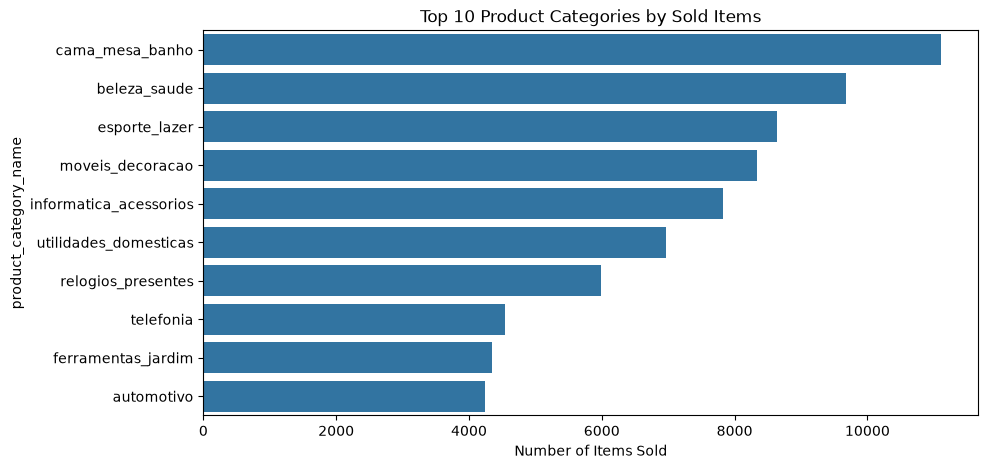

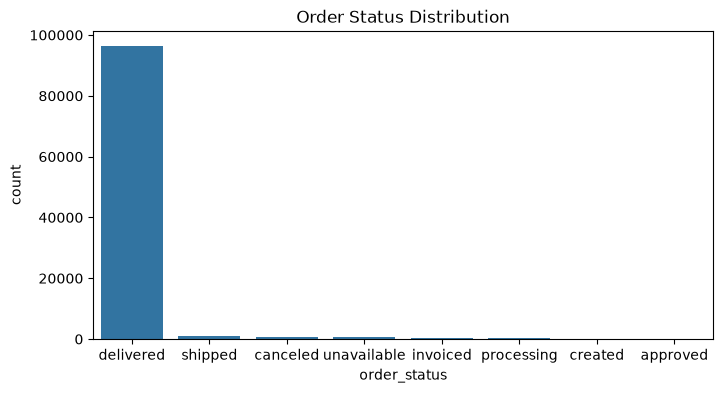

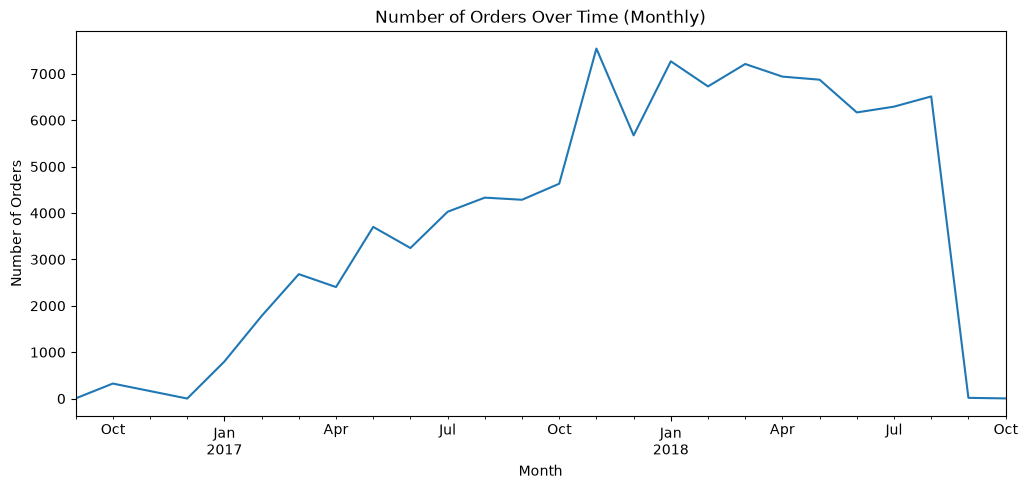

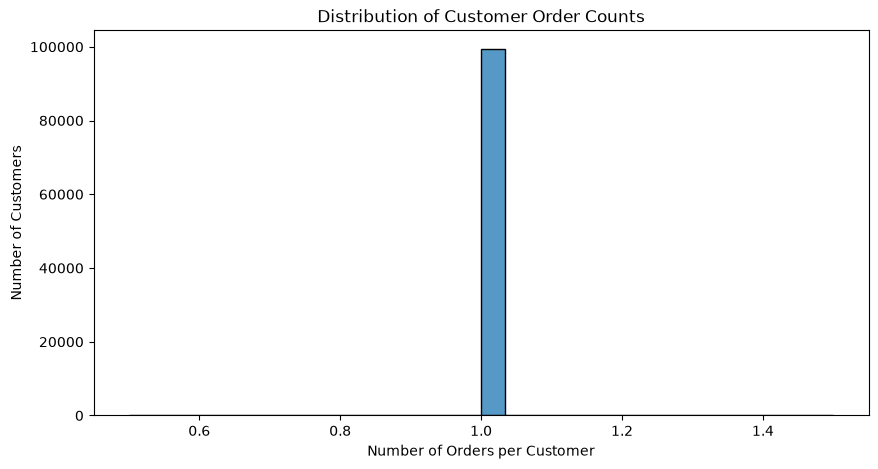

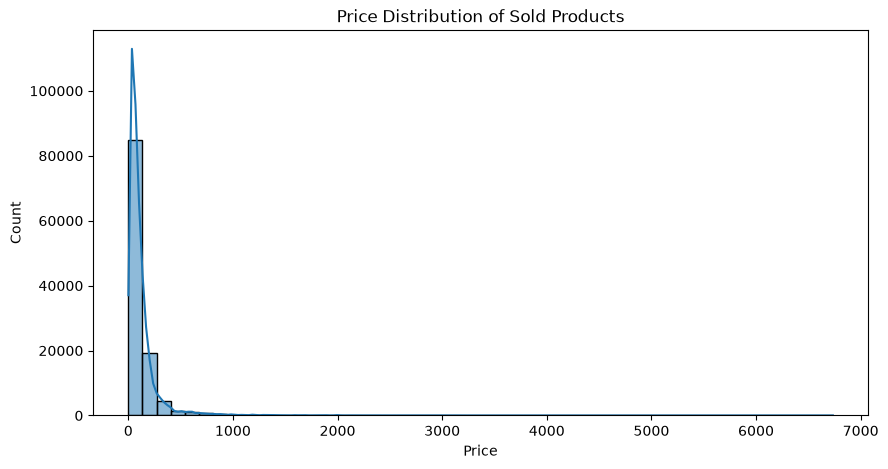

In [47]:
top_categories = full_data['product_category_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top 10 Product Categories by Sold Items')
plt.xlabel('Number of Items Sold')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=orders, x='order_status', order=orders['order_status'].value_counts().index)
plt.title('Order Status Distribution')
plt.show()

orders['order_purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders_by_month = orders['order_purchase_month'].value_counts().sort_index()
plt.figure(figsize=(12,5))
orders_by_month.plot(kind='line')
plt.title('Number of Orders Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

cust_order_counts = orders['customer_id'].value_counts()
plt.figure(figsize=(10,5))
sns.histplot(cust_order_counts, bins=30, kde=False)
plt.title('Distribution of Customer Order Counts')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(full_data['price'], bins=50, kde=True)
plt.title('Price Distribution of Sold Products')
plt.xlabel('Price')
plt.show()

In [48]:
# Memory-safe interaction matrix

top_products = full_data['product_id'].value_counts().head(1000).index

filtered_data = full_data[
    full_data['product_id'].isin(top_products)
]

interaction_small = filtered_data.groupby(
    ['customer_id', 'product_id']
).size().unstack(fill_value=0)

print("Interaction matrix shape:", interaction_small.shape)

Interaction matrix shape: (34809, 1000)


In [49]:
# Product Similarity Matrix

product_similarity_small = cosine_similarity(
    interaction_small.T
)

product_similarity_df_small = pd.DataFrame(
    product_similarity_small,
    index=interaction_small.columns,
    columns=interaction_small.columns
)

print("Similarity matrix shape:", product_similarity_df_small.shape)

Similarity matrix shape: (1000, 1000)


In [50]:
# Product Recommendation Function

def recommend_products(product_id, n=5):
    if product_id not in product_similarity_df_small.index:
        return "Product not found"

    similar_products = (
        product_similarity_df_small[product_id]
        .drop(product_id)
        .sort_values(ascending=False)
        .head(n)
    )

    return similar_products.index.tolist()


# Test recommendation
sample_product = interaction_small.columns[0]

print("Input Product:", sample_product)
print("Recommended Products:", recommend_products(sample_product, 5))

Input Product: 008cff0e5792219fae03e570f980b330
Recommended Products: ['00ba6d766f0b1d7b78a5ce3e1e033263', 'acc444eb5ad26f79d5a11baa6a03c439', 'a9f480bfc49f0b85e8394e1cdf685b4e', 'aa280035c50ba62c746480a59045eec4', 'aa5d6a9bd4be367ae1a3a29c323c7c11']


In [51]:
# Leakage-Free Evaluation using the 1000-product matrix

precision_scores = []
recall_scores = []

rng = np.random.default_rng(42)

for customer_id in interaction_small.index:

    purchased_products = interaction_small.loc[customer_id]
    purchased_products = purchased_products[purchased_products > 0].index.tolist()

    # Customer needs at least 2 purchased products
    if len(purchased_products) < 2:
        continue

    # Hold out one product as test item
    test_product = rng.choice(purchased_products)

    # Use another purchased product as query
    query_candidates = [
        p for p in purchased_products
        if p != test_product
    ]

    query_product = query_candidates[0]

    # Query product must exist in similarity matrix
    if query_product not in product_similarity_df_small.index:
        continue

    recommendations = (
        product_similarity_df_small[query_product]
        .drop(query_product)
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    # Check whether test product appears in recommendations
    hit = int(test_product in recommendations)

    precision_scores.append(hit / 5)
    recall_scores.append(hit)


print(f"Precision@5: {np.mean(precision_scores):.4f}")
print(f"Recall@5: {np.mean(recall_scores):.4f}")

Precision@5: 0.1972
Recall@5: 0.9859


In [52]:
# Create Train/Test Split

train_interaction = interaction_small.copy()
test_items = {}

rng = np.random.default_rng(42)

for customer_id in interaction_small.index:

    purchased = interaction_small.loc[customer_id]
    purchased_products = purchased[purchased > 0].index.tolist()

    if len(purchased_products) < 2:
        continue

    # Hold out one purchased product for testing
    test_product = rng.choice(purchased_products)

    test_items[customer_id] = test_product

    # Remove test product from training data
    train_interaction.loc[customer_id, test_product] = 0

print("Training matrix shape:", train_interaction.shape)
print("Test customers:", len(test_items))

Training matrix shape: (34809, 1000)
Test customers: 497


In [53]:
# Build Similarity Matrix Using Training Data Only

train_similarity = cosine_similarity(
    train_interaction.T
)

train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_interaction.columns,
    columns=train_interaction.columns
)

print("Training similarity matrix shape:", train_similarity_df.shape)

Training similarity matrix shape: (1000, 1000)


In [54]:
# Final Leakage-Free Evaluation

precision_scores = []
recall_scores = []

for customer_id, test_product in test_items.items():

    # Products this customer still has in training data
    train_purchased = train_interaction.loc[customer_id]
    train_purchased = train_purchased[train_purchased > 0].index.tolist()

    if len(train_purchased) == 0:
        continue

    # Use one training product as the query
    query_product = train_purchased[0]

    if query_product not in train_similarity_df.index:
        continue

    recommendations = (
        train_similarity_df[query_product]
        .drop(query_product)
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    hit = int(test_product in recommendations)

    precision_scores.append(hit / 5)
    recall_scores.append(hit)


print(f"Final Precision@5: {np.mean(precision_scores):.4f}")
print(f"Final Recall@5: {np.mean(recall_scores):.4f}")
print(f"Evaluated Customers: {len(precision_scores)}")

Final Precision@5: 0.0294
Final Recall@5: 0.1469
Evaluated Customers: 497


In [ ]:
print(full_data.columns.tolist())

In [55]:
# Product ID to Category Mapping

product_category_map = (
    full_data[['product_id', 'product_category_name']]
    .drop_duplicates('product_id')
    .set_index('product_id')['product_category_name']
    .to_dict()
)

print("Product-category mapping created:", len(product_category_map))

Product-category mapping created: 32951


In [56]:
# Add Category Information to Recommendations

sample_product = interaction_small.columns[0]

recommended_products = recommend_products(sample_product, 5)

recommendation_details = pd.DataFrame({
    'product_id': recommended_products,
    'category': [
        product_category_map.get(product_id, 'Unknown')
        for product_id in recommended_products
    ]
})

recommendation_details

,product_id,category
0,00ba6d766f0b1d7b78a5ce3e1e033263,utilidades_domesticas
1,acc444eb5ad26f79d5a11baa6a03c439,moveis_decoracao
2,a9f480bfc49f0b85e8394e1cdf685b4e,brinquedos
3,aa280035c50ba62c746480a59045eec4,brinquedos
4,aa5d6a9bd4be367ae1a3a29c323c7c11,esporte_lazer


In [57]:
# Business-Friendly Product Recommendations

sample_product = interaction_small.columns[0]

recommended_products = recommend_products(sample_product, 5)

recommendation_details = pd.DataFrame({
    'Recommended_Product_ID': recommended_products,
    'Category': [
        product_category_map.get(product_id, 'Unknown')
        for product_id in recommended_products
    ]
})

input_category = product_category_map.get(sample_product, 'Unknown')

print("Input Product:", sample_product)
print("Input Category:", input_category)
print("\nRecommended Products:")

recommendation_details

Input Product: 008cff0e5792219fae03e570f980b330
Input Category: esporte_lazer

Recommended Products:


,Recommended_Product_ID,Category
0,00ba6d766f0b1d7b78a5ce3e1e033263,utilidades_domesticas
1,acc444eb5ad26f79d5a11baa6a03c439,moveis_decoracao
2,a9f480bfc49f0b85e8394e1cdf685b4e,brinquedos
3,aa280035c50ba62c746480a59045eec4,brinquedos
4,aa5d6a9bd4be367ae1a3a29c323c7c11,esporte_lazer


In [58]:
import os

os.makedirs('data/processed', exist_ok=True)

recommendation_export.to_csv(
    'data/processed/sample_product_recommendations.csv',
    index=False
)

print("Recommendation file saved successfully.")

Recommendation file saved successfully.


In [59]:
# RFM Customer Segmentation

rfm = full_data.groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (full_data['order_purchase_timestamp'].max() - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,292,1,89.80
1,000161a058600d5901f007fab4c27140,413,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,551,1,179.99
3,0002414f95344307404f0ace7a26f1d5,382,1,149.90
4,000379cdec625522490c315e70c7a9fb,153,1,93.00


In [68]:
# Create RFM scores

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = (
    rfm['R_score'].astype(int) +
    rfm['F_score'].astype(int) +
    rfm['M_score'].astype(int)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,00012a2ce6f8dcda20d059ce98491703,292,1,89.80,2,1,3,6
1,000161a058600d5901f007fab4c27140,413,1,54.90,1,1,2,4
2,0001fd6190edaaf884bcaf3d49edf079,551,1,179.99,1,1,5,7
3,0002414f95344307404f0ace7a26f1d5,382,1,149.90,2,1,4,7
4,000379cdec625522490c315e70c7a9fb,153,1,93.00,4,1,3,8


In [71]:
# Segment-wise Business Analysis

segment_analysis = rfm.groupby('Customer_Segment').agg(
    Customers=('customer_id', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Revenue_Per_Customer=('Monetary', 'mean'),
    Avg_Frequency=('Frequency', 'mean')
).sort_values('Total_Revenue', ascending=False)

segment_analysis

,Customers,Total_Revenue,Avg_Revenue_Per_Customer,Avg_Frequency
Customer_Segment,,,,
Loyal Customers,33921,6212194.62,183.137131,1.0
Potential Customers,40704,4375351.60,107.491932,1.0
Champions,8015,2242564.78,279.795980,1.0
At Risk,12857,661211.46,51.428129,1.0
Lost Customers,3169,100321.24,31.657065,1.0


In [72]:
# Export Customer Segmentation Data

rfm.to_csv(
    'data/processed/customer_rfm_segments.csv',
    index=False
)

segment_analysis.to_csv(
    'data/processed/customer_segment_analysis.csv'
)

print("RFM files saved successfully.")

RFM files saved successfully.


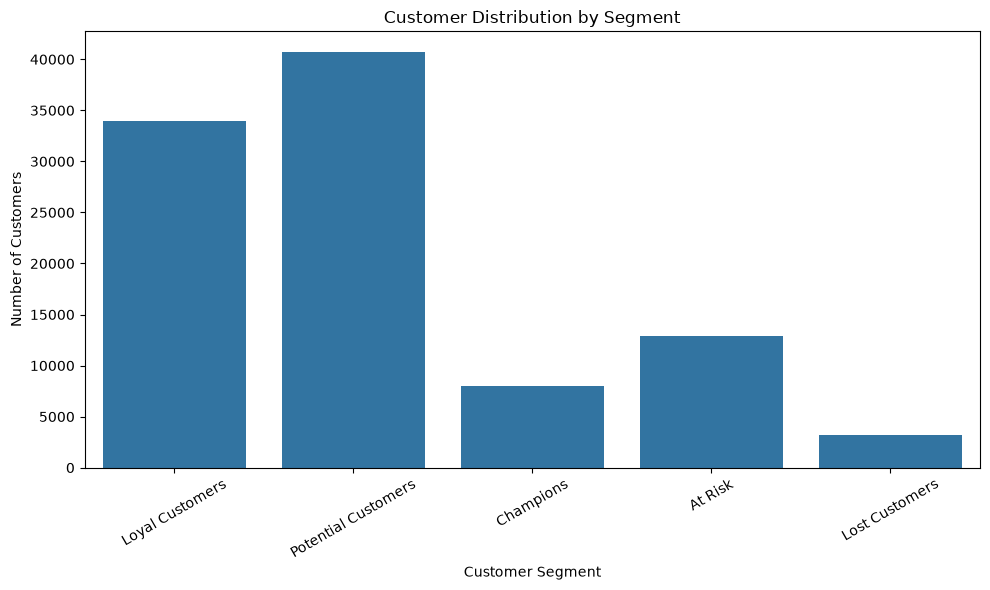

In [67]:
# Customer Segment Distribution

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis['Customers']
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [62]:
# Product Recommendation Function

def recommend_products(product_id, n=5):
    if product_id not in product_similarity_df_small.index:
        return "Product not found"

    similar_products = (
        product_similarity_df_small[product_id]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return similar_products.index.tolist()


# Example recommendation
recommend_products(interaction_small.columns[0], 5)

['aca2eb7d00ea1a7b8ebd4e68314663af',
 'a9516a079e37a9c9c36b9b78b10169e8',
 'a9f480bfc49f0b85e8394e1cdf685b4e',
 'aa280035c50ba62c746480a59045eec4',
 'aa5d6a9bd4be367ae1a3a29c323c7c11']

In [81]:
# Recommendation Evaluation - Precision@5

def precision_at_k(customer_id, k=5):
    # Products purchased by this customer
    purchased_products = set(
        interaction_small.loc[customer_id][
            interaction_small.loc[customer_id] > 0
        ].index
    )

    # Need at least 2 products for evaluation
    if len(purchased_products) < 2:
        return None

    # Use one purchased product as the query product
    query_product = list(purchased_products)[0]

    # Check whether query product exists in similarity matrix
    if query_product not in product_similarity_df_small.index:
        return None

    # Get top-k similar products
    recommendations = (
        product_similarity_df_small[query_product]
        .drop(query_product)
        .sort_values(ascending=False)
        .head(k)
        .index
    )

    # Count recommended products that customer actually purchased
    hits = len(set(recommendations) & purchased_products)

    return hits / k


# Evaluate across customers
precision_scores = []

for customer_id in interaction_small.index:
    score = precision_at_k(customer_id, k=5)

    if score is not None:
        precision_scores.append(score)

mean_precision_at_5 = np.mean(precision_scores)

print(f"Precision@5: {mean_precision_at_5:.4f}")
print(f"Evaluated Customers: {len(precision_scores)}")

Precision@5: 0.2064
Evaluated Customers: 497


In [76]:
# Memory-safe interaction matrix

top_products = full_data['product_id'].value_counts().head(1000).index

filtered_data = full_data[
    full_data['product_id'].isin(top_products)
]

interaction_small = filtered_data.groupby(
    ['customer_id', 'product_id']
).size().unstack(fill_value=0)

print(interaction_small.shape)

(34809, 1000)


In [77]:
# Export Product Similarity Matrix for Streamlit

product_similarity_df_small.to_csv(
    'data/processed/product_similarity_matrix.csv'
)

print("Product similarity matrix saved successfully.")

Product similarity matrix saved successfully.
